1/6 - Chargement des données...
2/6 - Nettoyage (Moyenne) et Scaling...
3/6 - Optimisation des modèles (cela peut prendre 15-20 min)...
--- Entraînement : Ridge ---
--- Entraînement : KNN ---
--- Entraînement : HistGB ---

--- SYNTHÈSE DES PERFORMANCES ---
   Modèle        R2        RMSE         MAE
0   Ridge  0.545548  265.321530  234.248073
1     KNN  0.186262  355.034811  161.780186
2  HistGB  0.917395  113.118020   71.567263
4/6 - Génération des courbes d'optimisation...


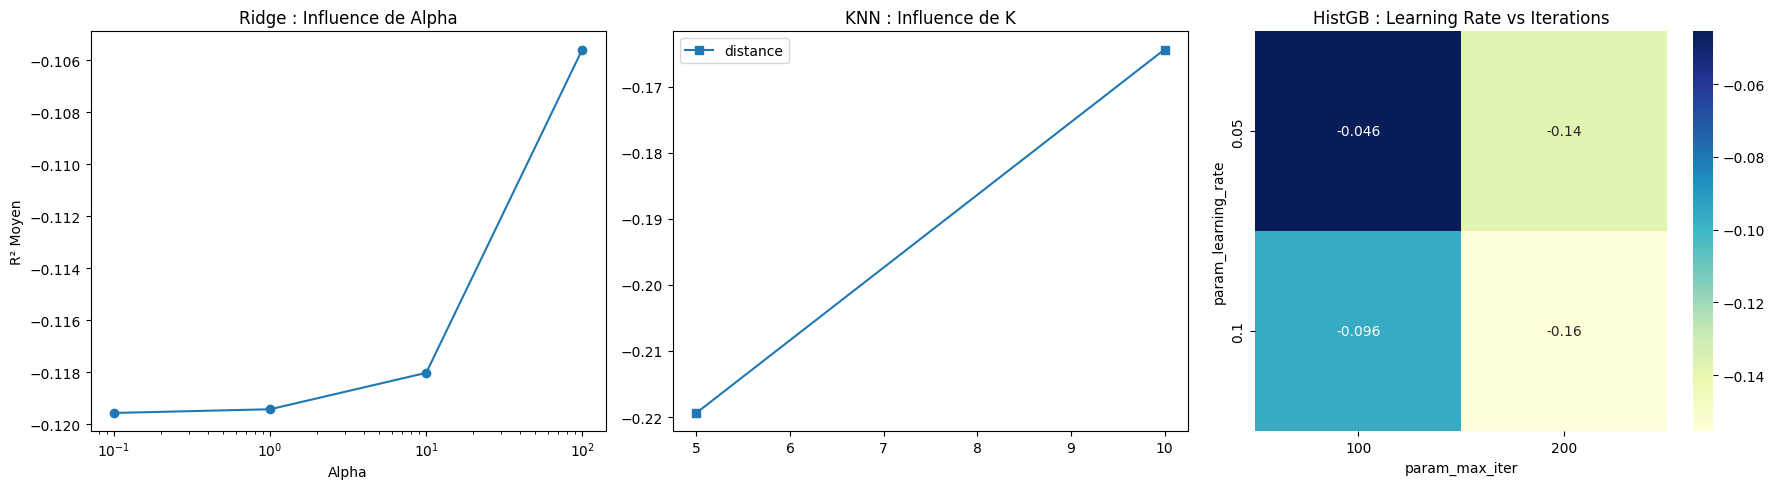

5/6 - Analyse des variables et des erreurs...


/tmp/ipython-input-1404405900.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Imp', y='Var', data=imp_df, palette='viridis')


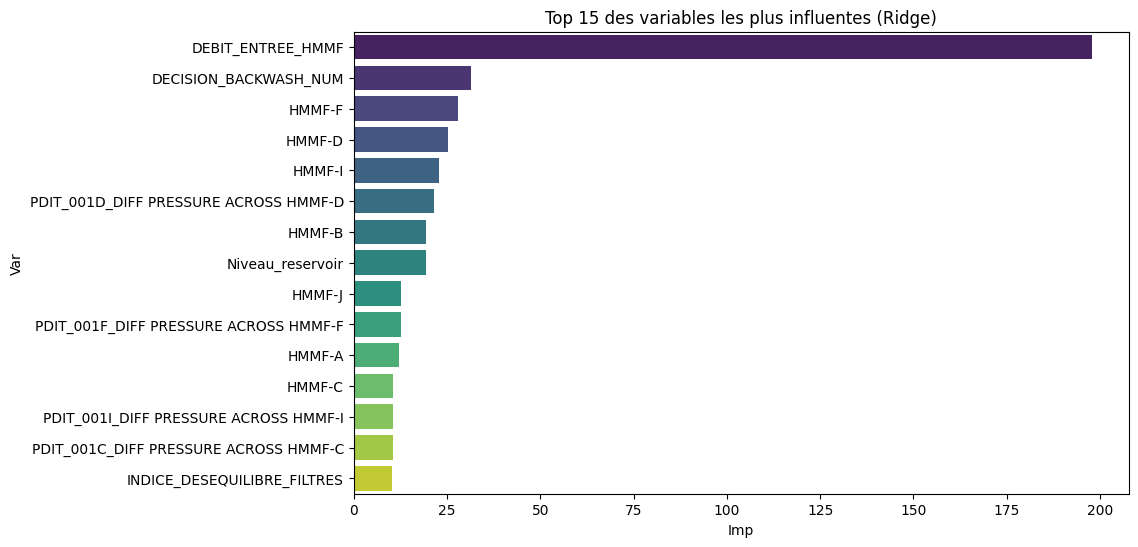

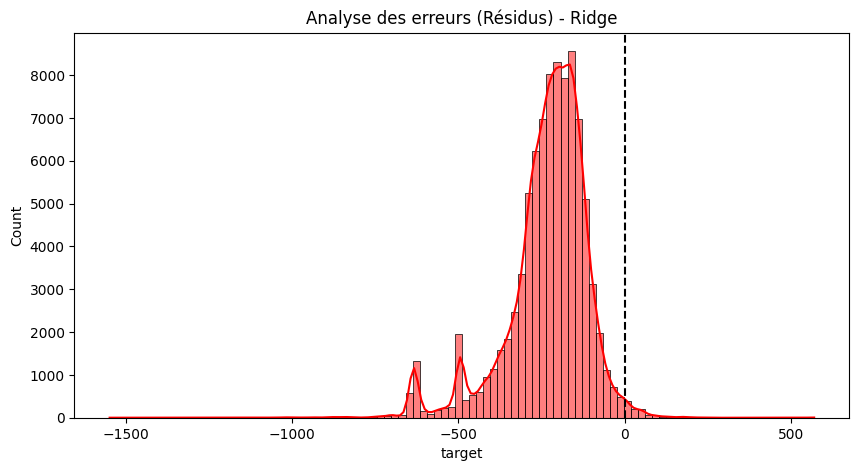

6/6 - Graphiques de comparaison finaux...


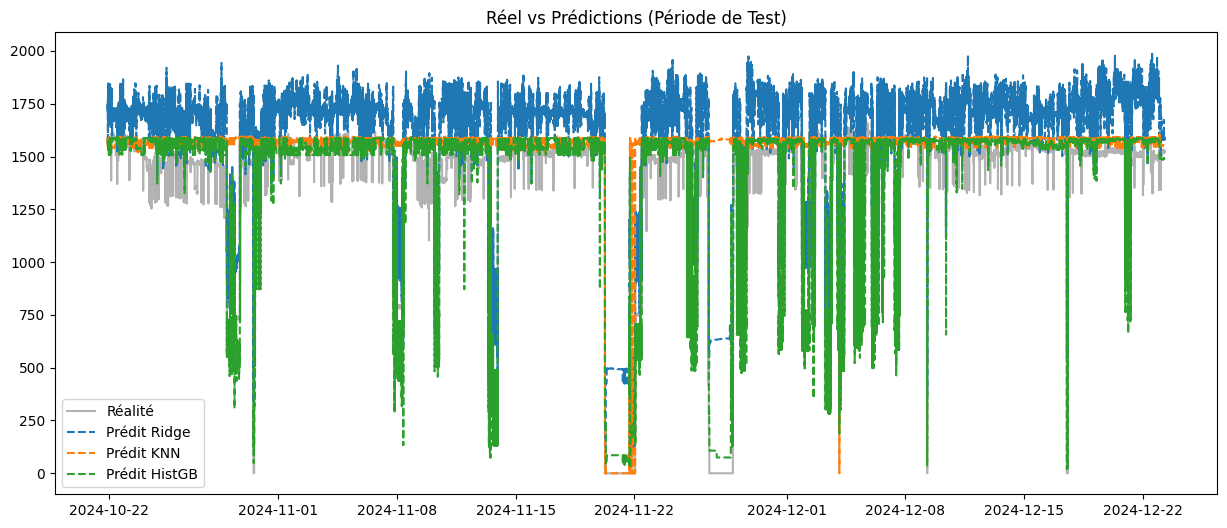

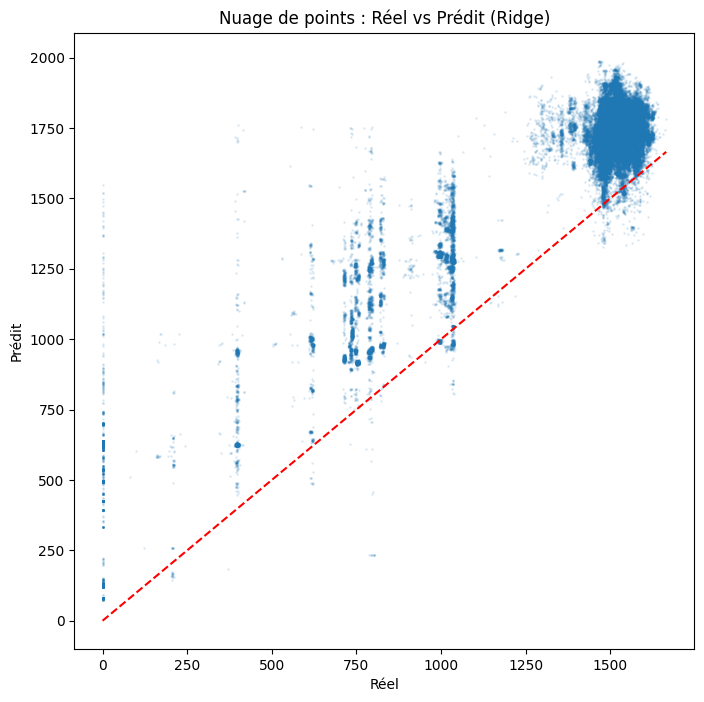


--- TERMINÉ ---
Tu peux maintenant télécharger les fichiers .pkl dans le menu à gauche.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==========================================
# 1. CHARGEMENT ET PRÉPARATION
# ==========================================
print("1/6 - Chargement des données...")
# Chargement du fichier (vérifie bien le nom du fichier sur ton Colab)
df = pd.read_csv('data_prod_finale.csv', parse_dates=['time'], index_col='time')
df = df.sort_index()

X = df.drop(columns=['target'])
y = df['target']

# Split chronologique (80% train / 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ==========================================
# 2. NETTOYAGE ET NORMALISATION
# ==========================================
print("2/6 - Nettoyage (Moyenne) et Scaling...")
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

# On apprend sur le train, on applique sur test (évite le data leakage)
X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_test_scaled = scaler.transform(imputer.transform(X_test_raw))

# ==========================================
# 3. CONFIGURATION ET ENTRAÎNEMENT (GRIDSEARCH)
# ==========================================
print("3/6 - Optimisation des modèles (cela peut prendre 15-20 min)...")
tscv = TimeSeriesSplit(n_splits=3)

model_configs = {
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.1, 1, 10, 100]}
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [5, 10], 'weights': ['distance']}
    },
    'HistGB': {
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {
            'max_iter': [100, 200],
            'learning_rate': [0.1, 0.05]
        }
    }
}

saved_grids = {}
results = []
best_preds = {}

for name, config in model_configs.items():
    print(f"--- Entraînement : {name} ---")
    grid = GridSearchCV(config['model'], config['params'], cv=tscv, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    saved_grids[name] = grid
    best_m = grid.best_estimator_

    # Sauvegarde physique
    joblib.dump(best_m, f'model_{name}_final.pkl')

    y_pred = best_m.predict(X_test_scaled)
    best_preds[name] = y_pred

    results.append({
        'Modèle': name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

df_res = pd.DataFrame(results)
print("\n--- SYNTHÈSE DES PERFORMANCES ---")
print(df_res)

# ==========================================
# 4. GRAPHIQUES D'OPTIMISATION (GRIDSEARCH)
# ==========================================
print("4/6 - Génération des courbes d'optimisation...")
plt.figure(figsize=(18, 5))

# Ridge Alpha
plt.subplot(1, 3, 1)
res_ridge = pd.DataFrame(saved_grids['Ridge'].cv_results_)
plt.plot(res_ridge['param_alpha'], res_ridge['mean_test_score'], marker='o')
plt.xscale('log')
plt.title('Ridge : Influence de Alpha')
plt.xlabel('Alpha')
plt.ylabel('R² Moyen')

# KNN Neighbors
plt.subplot(1, 3, 2)
res_knn = pd.DataFrame(saved_grids['KNN'].cv_results_)
for w in res_knn['param_weights'].unique():
    sub = res_knn[res_knn['param_weights'] == w]
    plt.plot(sub['param_n_neighbors'], sub['mean_test_score'], marker='s', label=w)
plt.title('KNN : Influence de K')
plt.legend()

# HistGB Heatmap
plt.subplot(1, 3, 3)
res_hgb = pd.DataFrame(saved_grids['HistGB'].cv_results_)
pivot_hgb = res_hgb.pivot(index='param_learning_rate', columns='param_max_iter', values='mean_test_score')
sns.heatmap(pivot_hgb, annot=True, cmap='YlGnBu')
plt.title('HistGB : Learning Rate vs Iterations')

plt.tight_layout()
plt.show()

# ==========================================
# 5. IMPORTANCE DES VARIABLES ET RÉSIDUS
# ==========================================
print("5/6 - Analyse des variables et des erreurs...")

# Importance des variables (via Ridge)
coeffs = saved_grids['Ridge'].best_estimator_.coef_
imp_df = pd.DataFrame({'Var': X.columns, 'Imp': np.abs(coeffs)}).sort_values(by='Imp', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Imp', y='Var', data=imp_df, palette='viridis')
plt.title('Top 15 des variables les plus influentes (Ridge)')
plt.show()

# Distribution des résidus (Modèle Ridge)
residuals = y_test - best_preds['Ridge']
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=100, color='red')
plt.axvline(0, color='black', linestyle='--')
plt.title('Analyse des erreurs (Résidus) - Ridge')
plt.show()

# ==========================================
# 6. GRAPHIQUE TEMPOREL ET SCATTER PLOT
# ==========================================
print("6/6 - Graphiques de comparaison finaux...")

# Comparaison Temporelle
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test.values, label='Réalité', color='black', alpha=0.3)
for name, pred in best_preds.items():
    plt.plot(y_test.index, pred, label=f'Prédit {name}', linestyle='--')
plt.title('Réel vs Prédictions (Période de Test)')
plt.legend()
plt.show()

# Scatter Plot Réel vs Prédit
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds['Ridge'], alpha=0.1, s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Nuage de points : Réel vs Prédit (Ridge)')
plt.xlabel('Réel')
plt.ylabel('Prédit')
plt.show()

print("\n--- TERMINÉ ---")
print("Tu peux maintenant télécharger les fichiers .pkl dans le menu à gauche.")

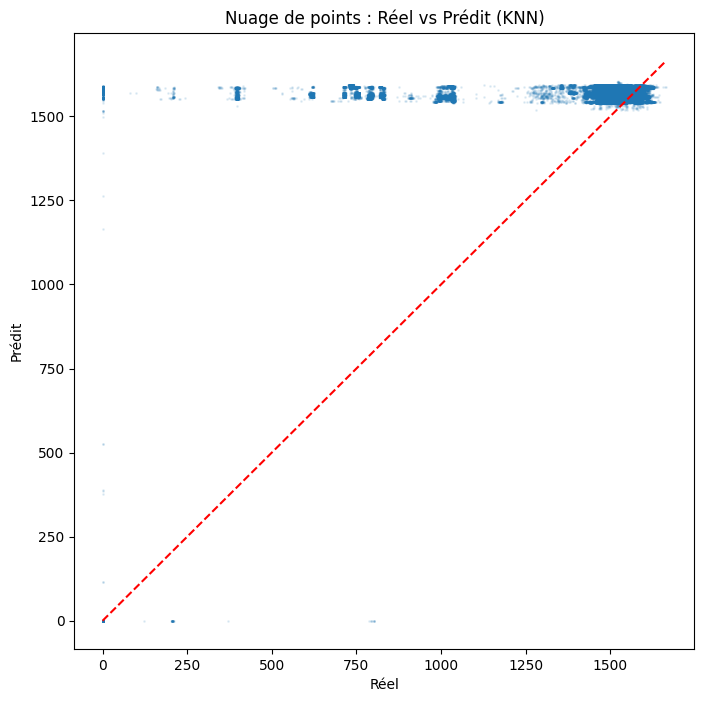

In [2]:
# Scatter Plot Réel vs Prédit
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds['KNN'], alpha=0.1, s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Nuage de points : Réel vs Prédit (KNN)')
plt.xlabel('Réel')
plt.ylabel('Prédit')
plt.show()

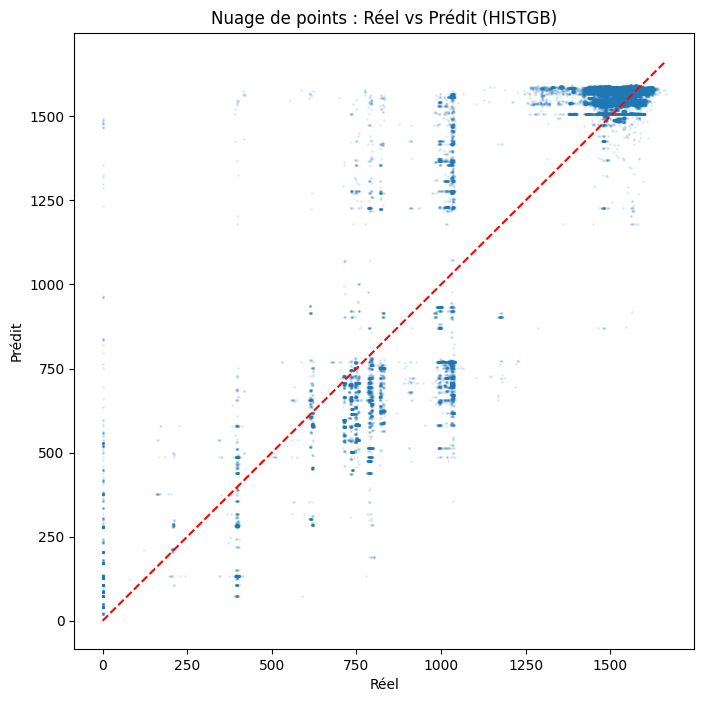

In [3]:
# Scatter Plot Réel vs Prédit
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds['HistGB'], alpha=0.1, s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Nuage de points : Réel vs Prédit (HISTGB)')
plt.xlabel('Réel')
plt.ylabel('Prédit')
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 449002 entries, 2024-02-13 11:38:00 to 2024-12-23 06:59:00
Data columns (total 32 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   Niveau_reservoir                       449002 non-null  float64
 1   DECISION_BACKWASH_NUM                  449002 non-null  int64  
 2   DP_moyen_filtres                       449002 non-null  float64
 3   type_backwash                          449002 non-null  int64  
 4   duree_backwash                         449002 non-null  float64
 5   intervalle_min                         449001 non-null  float64
 6   freq_backwash                          449002 non-null  float64
 7   INDICE_ENCRASSEMENT_HMMF               449002 non-null  float64
 8   DEBIT_ENTREE_HMMF                      449002 non-null  float64
 9   INDICE_IMPACT_PRODUCTION               449002 non-null  float64
 10  INDICE_DESEQUILIBRE_FI

In [5]:
joblib.dump(imputer, 'imputer_final.pkl')
joblib.dump(scaler, 'scaler_final.pkl')

['scaler_final.pkl']

In [8]:
import pandas as pd
import joblib
import numpy as np

# 1. CHARGEMENT DES COMPOSANTS
# Assure-toi que ces fichiers sont présents dans ton dossier Colab
model = joblib.load('model_Ridge_final.pkl')
scaler = joblib.load('scaler_final.pkl')
imputer = joblib.load('imputer_final.pkl')

# 2. LISTE OFFICIELLE DES COLONNES D'ENTRÉE (ORDRE CRITIQUE)
features_list = [
    'Niveau_reservoir', 'DECISION_BACKWASH_NUM', 'DP_moyen_filtres', 'type_backwash',
    'duree_backwash', 'intervalle_min', 'freq_backwash', 'INDICE_ENCRASSEMENT_HMMF',
    'DEBIT_ENTREE_HMMF', 'INDICE_IMPACT_PRODUCTION', 'INDICE_DESEQUILIBRE_FILTRES',
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B',
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D',
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F',
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H',
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J',
    'HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF-E', 'HMMF-F', 'HMMF-G', 'HMMF-H',
    'HMMF-I', 'HMMF-J'
]


# 3. EXEMPLE DE NOUVELLES DONNÉES (Remplis avec tes valeurs réelles)
data_test = {
    'Niveau_reservoir': [250.0],
    'DECISION_BACKWASH_NUM': [0],
    'DP_moyen_filtres': [30.15],
    'type_backwash': [1],
    'duree_backwash': [45.0],
    'intervalle_min': [14.0],  # Remplace NaN par une valeur si nécessaire
    'freq_backwash': [0.05],
    'INDICE_ENCRASSEMENT_HMMF': [1.2],
    'DEBIT_ENTREE_HMMF': [1500.0],
    'INDICE_IMPACT_PRODUCTION': [0.95],
    'INDICE_DESEQUILIBRE_FILTRES': [0.02],
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A': [12.5],
    'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B': [11.8],
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C': [13.2],
    'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D': [12.9],
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E': [11.5],
    'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F': [14.1],
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G': [12.7],
    'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H': [13.0],
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I': [12.4],
    'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J': [13.5],
    'HMMF-A': [1], 'HMMF-B': [1], 'HMMF-C': [1], 'HMMF-D': [1], 'HMMF-E': [1],
    'HMMF-F': [1], 'HMMF-G': [1], 'HMMF-H': [1], 'HMMF-I': [1], 'HMMF-J': [1]
}


# 4. CRÉATION DU DATAFRAME ET PIPELINE
X_new = pd.DataFrame(data_test)

# Sécurité : On s'assure que toutes les colonnes sont présentes et dans le bon ordre
X_new = X_new.reindex(columns=features_list)

# Étape A : Imputation (pour gérer les NaNs éventuels comme dans intervalle_min)
X_imputed = imputer.transform(X_new)

# Étape B : Standardisation (pour remettre les valeurs à l'échelle du modèle)
X_scaled = scaler.transform(X_imputed)

# Étape C : Prédiction finale
prediction = model.predict(X_scaled)

print("-" * 40)
print(f"RÉSULTAT DE LA PRÉDICTION : {prediction[0]:.4f}")
print("-" * 40)

----------------------------------------
RÉSULTAT DE LA PRÉDICTION : 2742.3512
----------------------------------------
